In [36]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
print("tensorflow:", tf.__version__)

X_train = np.load("../data/processed/X_train.npy")
X_test = np.load("../data/processed/X_test.npy")
y_train = np.load("../data/processed/y_train.npy")
y_test = np.load("../data/processed/y_test.npy")

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

tensorflow: 2.21.0
X_train: (242, 18)
X_test: (61, 18)
y_train: (242,)
y_test: (61,)


In [37]:
### input ( 18 features ) --> Dense (32 neuron) --> ReLu (activation fn) --> Dense (16) --> ReLu(activation fn) --> Dense (1) --> sigmoid ( converts the output between 0-1 )
## building the baseline model
model  = keras.Sequential([    ### sequential creates a empty model which process data through layers
    keras.layers.Input(shape=(18,)),
    keras.layers.Dense(32,activation="relu"),
    keras.layers.Dense(16,activation="relu"),
    keras.layers.Dense(1,activation="sigmoid")

])
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 32)             │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153 (4.50 KB)

 Trainable params: 1,153 (4.50 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
### model compiling
model.compile(   ### compile -- configures the learning of the model
    optimizer = "adam", ### optimizer updates the weight during training
    loss = "binary_crossentropy",  ### loss tells how wrong is the model prediction is
    metrics = ["accuracy"]
)

In [39]:
### training the model
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5337 - loss: 0.6977 - val_accuracy: 0.5510 - val_loss: 0.6840
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6528 - loss: 0.6486 - val_accuracy: 0.6122 - val_loss: 0.6567
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7409 - loss: 0.6093 - val_accuracy: 0.7143 - val_loss: 0.6244
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7668 - loss: 0.5770 - val_accuracy: 0.7347 - val_loss: 0.5981
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7876 - loss: 0.5490 - val_accuracy: 0.6939 - val_loss: 0.5725
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7772 - loss: 0.5219 - val_accuracy: 0.7551 - val_loss: 0.5477
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7876 - loss: 0.4940 - val_accuracy: 0.8163 - val_loss: 0.5292
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7979 - loss: 0.4697 - val_accuracy: 0.7959 - val_loss

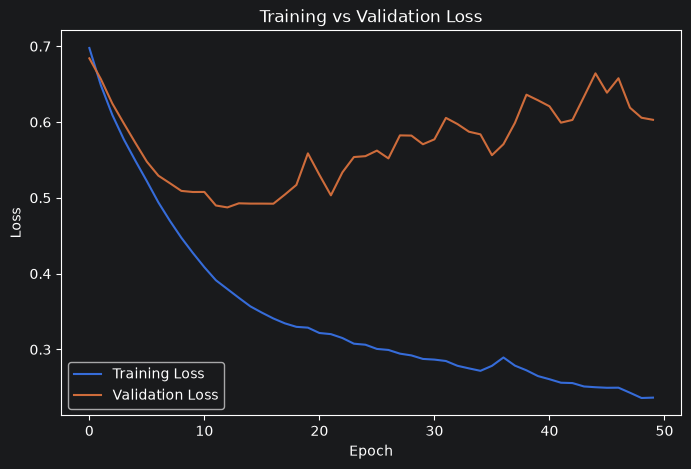

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

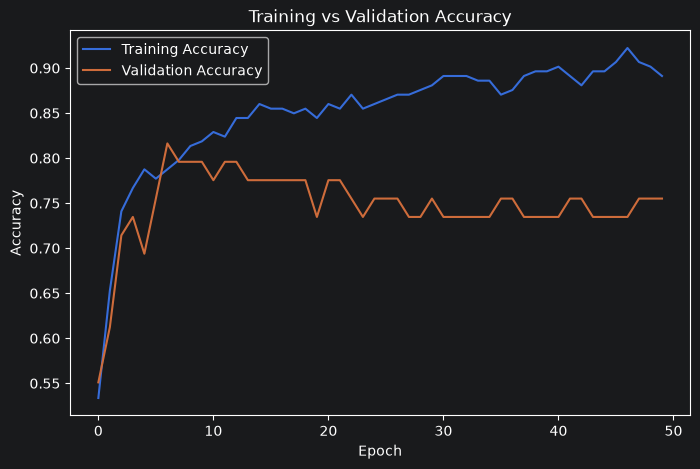

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

In [42]:
### early stopping call back
early_stopping = keras.callbacks.EarlyStopping(
    monitor = "val_loss",  ### which metrics to looks for
    patience = 5,    ### wait for 5 epoch if the val doesnt improve it stops
    restore_best_weights = True  ### restores the best weight
)

In [43]:
### training again with the changes
history_es = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9067 - loss: 0.2315 - val_accuracy: 0.7551 - val_loss: 0.6192
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9171 - loss: 0.2290 - val_accuracy: 0.7551 - val_loss: 0.6208
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9067 - loss: 0.2262 - val_accuracy: 0.7551 - val_loss: 0.6119
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9016 - loss: 0.2244 - val_accuracy: 0.7551 - val_loss: 0.6161
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9119 - loss: 0.2217 - val_accuracy: 0.7551 - val_loss: 0.6302
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9223 - loss: 0.2198 - val_accuracy: 0.7551 - val_loss: 0.6452
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9223 - loss: 0.2215 - val_accuracy: 0.7551 - val_loss: 0.6589
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9223 - loss: 0.2184 - val_accuracy: 0.7551 - val_loss:

In [44]:
print("Epochs actually trained:", len(history_es.history["loss"]))

best_epoch = np.argmin(history_es.history["val_loss"]) + 1
best_val_loss = min(history_es.history["val_loss"])

print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)

Epochs actually trained: 8
Best epoch: 3
Best validation loss: 0.611915111541748


In [45]:
### creating the model again
## fresh model
def  create_model():
    model = keras.Sequential([
        keras.layers.Input(shape=(18,)),
        keras.layers.Dense(32,activation="relu"),
        keras.layers.Dense(16,activation="relu"),
        keras.layers.Dense(1,activation="sigmoid")
    ])
    model.compile(
        optimizer = "adam",
        loss = "binary_crossentropy",
        metrics = ["accuracy"]
    )
    return model

In [46]:
model_es = create_model()
model_es.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 32)             │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153 (4.50 KB)

 Trainable params: 1,153 (4.50 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
### fresh callback
early_stopping_es = keras.callbacks.EarlyStopping(
    monitor = "val_loss",
    patience = 5,
    restore_best_weights = True
)

In [48]:
history_es = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    callbacks=[early_stopping_es],
    verbose=1
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8964 - loss: 0.2240 - val_accuracy: 0.7551 - val_loss: 0.6130
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9016 - loss: 0.2230 - val_accuracy: 0.7551 - val_loss: 0.6267
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9119 - loss: 0.2186 - val_accuracy: 0.7551 - val_loss: 0.6264
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9119 - loss: 0.2168 - val_accuracy: 0.7551 - val_loss: 0.6201
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9119 - loss: 0.2147 - val_accuracy: 0.7551 - val_loss: 0.6241
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9171 - loss: 0.2118 - val_accuracy: 0.7551 - val_loss: 0.6298


In [49]:
print("Epochs actually trained:", len(history_es.history["loss"]))

best_epoch = np.argmin(history_es.history["val_loss"]) + 1
best_val_loss = min(history_es.history["val_loss"])

print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)

Epochs actually trained: 6
Best epoch: 1
Best validation loss: 0.6130044460296631


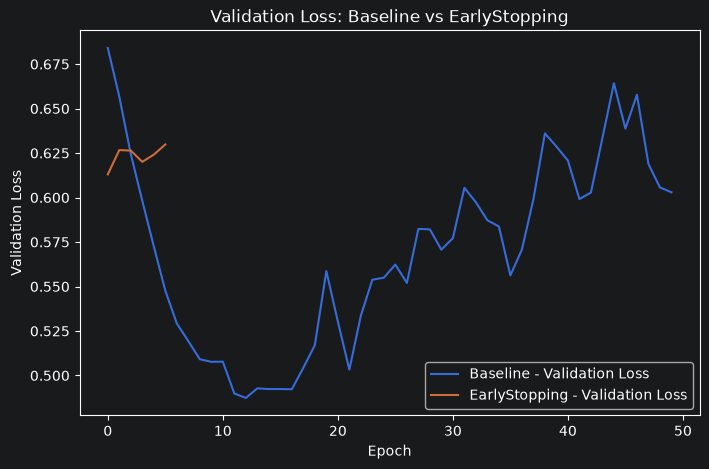

In [50]:
### visualize and compare the baseline and earlystopping ---- this is done to check whether the model is improved
## compare baseline loss and earlystopping loss
# to check does earlystopping improve model's generaization


### comparing validation loss
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(
    history.history["val_loss"],
    label="Baseline - Validation Loss"
)
plt.plot(
    history_es.history["val_loss"],
    label="EarlyStopping - Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss: Baseline vs EarlyStopping")

plt.legend()
plt.show()


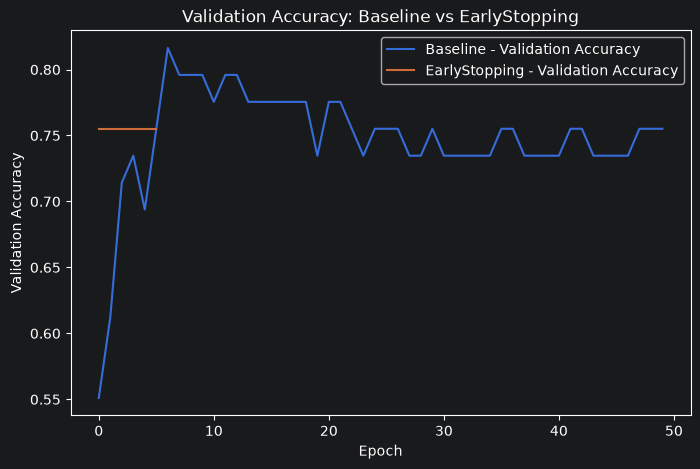

In [51]:
### comparing validation accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(
    history.history["val_accuracy"],
    label = "Baseline - Validation Accuracy"

)
plt.plot(
    history_es.history["val_accuracy"],
    label = "EarlyStopping - Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy: Baseline vs EarlyStopping")
plt.legend()
plt.show()


In [52]:
### regularization --- dropout model
def create_dropout_model():
    model = keras.Sequential([
        keras.layers.Input(shape=(18,)),

        keras.layers.Dense(32,activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(16,activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(1,activation="sigmoid")
    ])
    model.compile(
        optimizer = "adam",
        loss = "binary_crossentropy",
        metrics = ["accuracy"]
    )
    return model


In [53]:
model_dropout = create_dropout_model()
model_dropout.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 32)             │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153 (4.50 KB)

 Trainable params: 1,153 (4.50 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
early_stopping_dropout = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [55]:
history_dropout = model_dropout.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    callbacks=[early_stopping_dropout],
    verbose=1
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5492 - loss: 0.7884 - val_accuracy: 0.4694 - val_loss: 0.7853
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5440 - loss: 0.7826 - val_accuracy: 0.4694 - val_loss: 0.7441
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4870 - loss: 0.7310 - val_accuracy: 0.4694 - val_loss: 0.7058
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5803 - loss: 0.6842 - val_accuracy: 0.5510 - val_loss: 0.6797
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5440 - loss: 0.6728 - val_accuracy: 0.5714 - val_loss: 0.6597
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6166 - loss: 0.6376 - val_accuracy: 0.5510 - val_loss: 0.6463
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6114 - loss: 0.6456 - val_accuracy: 0.6122 - val_loss: 0.6212
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6528 - loss: 0.6321 - val_accuracy: 0.6327 - val_loss

In [56]:
print("Epochs actually trained:", len(history_dropout.history["loss"]))

best_epoch_dropout = np.argmin(
    history_dropout.history["val_loss"]
) + 1

best_val_loss_dropout = min(
    history_dropout.history["val_loss"]
)

best_val_accuracy_dropout = max(
    history_dropout.history["val_accuracy"]
)

print("Best epoch:", best_epoch_dropout)
print("Best validation loss:", best_val_loss_dropout)
print("Best validation accuracy:", best_val_accuracy_dropout)

Epochs actually trained: 26
Best epoch: 21
Best validation loss: 0.4807090759277344
Best validation accuracy: 0.8163265585899353


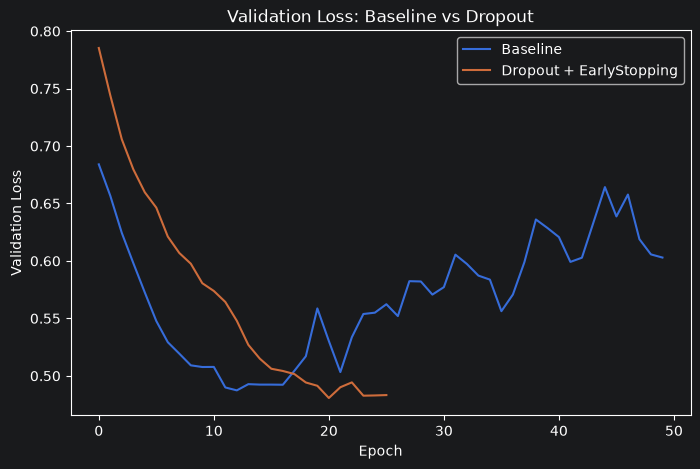

In [57]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["val_loss"],
    label="Baseline"
)

plt.plot(
    history_dropout.history["val_loss"],
    label="Dropout + EarlyStopping"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss: Baseline vs Dropout")
plt.legend()
plt.show()

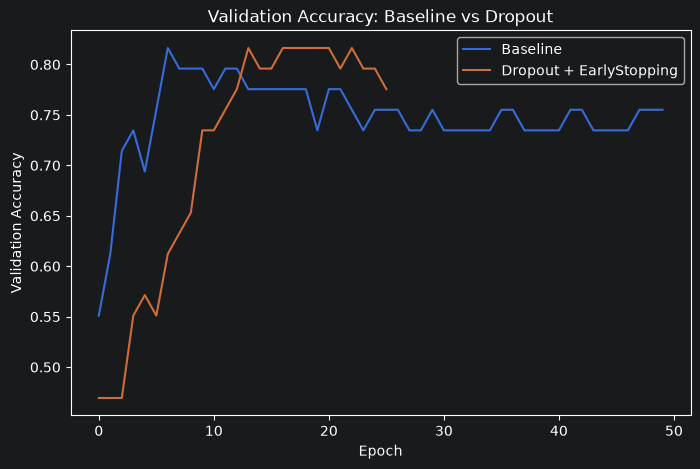

In [58]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["val_accuracy"],
    label="Baseline"
)

plt.plot(
    history_dropout.history["val_accuracy"],
    label="Dropout + EarlyStopping"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy: Baseline vs Dropout")
plt.legend()
plt.show()

In [59]:
### evaluating the drop out model
test_loss , test_accuracy = model_dropout.evaluate(
    X_test,
    y_test,
    verbose=0
)
print("test loss:", test_loss)
print("test accuracy:", test_accuracy)

test loss: 0.4056394696235657
test accuracy: 0.868852436542511


In [60]:
### evaluating the baseline model too
baseline_test_loss, baseline_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)
print("baseline test loss:", baseline_test_loss)
print("baselinee test accuracy:", baseline_accuracy)

baseline test loss: 0.3909786343574524
baselinee test accuracy: 0.8360655903816223


In [61]:
### tho both model ( baseline and dropout ) have same accuracy but the loss is different which tells the confidence of the model . accuracy checks whether the prediction is correct or not but the loss tells how correct and confidence of the prediction

In [62]:
### probabilites from dropout model
y_prob_dropout = model_dropout.predict(
    X_test,
    verbose=0
).ravel() ## ravel() flatens multidimensional array into 1D
y_pred_dropout = (y_prob_dropout >=0.5).astype(int)

print("first 10 probabilities: ", y_prob_dropout[:10])
print("first 10 predictions:", y_pred_dropout[:10])

first 10 probabilities:  [0.25994414 0.6334652  0.33791953 0.05901856 0.6040248  0.30698666
 0.21228378 0.44304392 0.5476489  0.31982115]
first 10 predictions: [0 1 0 0 1 0 0 0 1 0]


In [63]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_dropout)
print (" confusion matrix:")
print(cm)

 confusion matrix:
[[30  3]
 [ 5 23]]


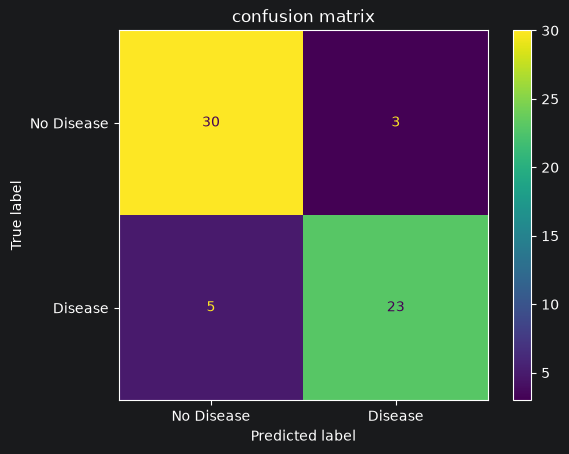

In [64]:
### representing the confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]

).plot()
plt.title("confusion matrix")
plt.show()

In [65]:
from sklearn.metrics import (
        accuracy_score,
        precision_score,
        recall_score,
        f1_score
 )
accuracy = accuracy_score(y_test, y_pred_dropout)
precision = precision_score(y_test, y_pred_dropout)
recall = recall_score(y_test, y_pred_dropout)
f1 = f1_score(y_test, y_pred_dropout)
print("accuracy:", accuracy)
print("precision:", precision)
print("recall:", recall)
print("f1:",f1)



accuracy: 0.8688524590163934
precision: 0.8846153846153846
recall: 0.8214285714285714
f1: 0.8518518518518519


In [66]:
from sklearn.metrics import classification_report
report = classification_report(
    y_test,
    y_pred_dropout,
    target_names = ["No Disease", "Disease"]
)
print(report)

              precision    recall  f1-score   support

  No Disease       0.86      0.91      0.88        33
     Disease       0.88      0.82      0.85        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



In [67]:
### creating ROC and AUROC
from sklearn.metrics import roc_curve , roc_auc_score
fpr,tpr,thresholds = roc_curve(
    y_test,
    y_prob_dropout
)
auroc = roc_auc_score(
    y_test,
    y_prob_dropout
)

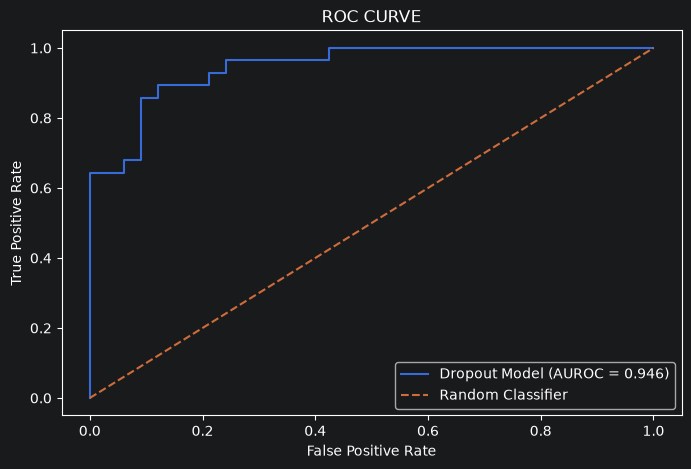

In [68]:
### ploting the curve
plt.figure(figsize=(8, 5))
plt.plot(
    fpr, ### fpr xaxis
    tpr,  ### tpr yaxis
    label=f"Dropout Model (AUROC = {auroc:.3f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC CURVE")
plt.legend()
plt.show()

In [69]:
### L2 REGULARIZATION --- adds penalty when the models weight become too large
def create_l2_model():
    model = keras.Sequential([
        keras.layers.Input(shape=(18,)),
        keras.layers.Dense(
            32,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(0.001),  ### penalizes the large weight

        ),
        keras.layers.Dense(
            16,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(0.001)
        ),
        keras.layers.Dense(
            1,
            activation="sigmoid"
        )
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [70]:
model_l2 = create_l2_model()
model_l2.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 32)             │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153 (4.50 KB)

 Trainable params: 1,153 (4.50 KB)

 Non-trainable params: 0 (0.00 B)

In [71]:
### early stopping for l2
early_stopping_l2 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [72]:
history_l2 = model_l2.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    callbacks=[early_stopping_l2],
    verbose=1
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5233 - loss: 0.7357 - val_accuracy: 0.6327 - val_loss: 0.7098
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6477 - loss: 0.6997 - val_accuracy: 0.6531 - val_loss: 0.6981
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7461 - loss: 0.6747 - val_accuracy: 0.6735 - val_loss: 0.6844
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7409 - loss: 0.6525 - val_accuracy: 0.7143 - val_loss: 0.6653
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7876 - loss: 0.6291 - val_accuracy: 0.7755 - val_loss: 0.6308
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8083 - loss: 0.6022 - val_accuracy: 0.7959 - val_loss: 0.6070
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8031 - loss: 0.5797 - val_accuracy: 0.7959 - val_loss: 0.5763
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7824 - loss: 0.5643 - val_accuracy: 0.7959 - val_loss